# Notebook 4: Environmental Risk

Adds two environmental risk modifiers:
- **Contamination proximity**: distance to nearest EPA Superfund NPL site in WA
- **Waterway sensitivity**: proximity to major regulated rivers (Columbia, Snake, Spokane, Skagit, Yakima)
  as a proxy for ESA thermal discharge risk and water withdrawal scrutiny.

| Layer | Source |
|---|---|
| Superfund NPL sites | EPA NPL State List (hardcoded ~26 active WA sites) |
| Major waterways | Sample points along key WA rivers, IDW to grid |
| Grid | static/grid_scores.geojson (NB3 output, 974 cells) |


In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")

RAW       = Path("data/raw")
PROCESSED = Path("data/processed")
DARK_BG   = "#1a1a2e"
WHITE     = "white"

plt.rcParams.update({
    "text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE, "font.size": 16,
})
print("Imports OK")


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Imports OK


## 1. Load grid and boundaries


In [2]:
wa     = gpd.read_file(RAW / "wa_state.geojson").to_crs("EPSG:32610")
dc_gdf = gpd.read_file(RAW / "datacenters.geojson").to_crs("EPSG:32610")
grid   = gpd.read_file("static/grid_scores.geojson").to_crs("EPSG:32610")

grid["centroid"] = grid.geometry.centroid
tgt_x = np.array([c.x for c in grid.centroid])
tgt_y = np.array([c.y for c in grid.centroid])
grid_coords = np.column_stack([tgt_x, tgt_y])

print(f"Grid: {len(grid)} cells")
print(f"Columns: {list(grid.columns)}")


Grid: 974 cells
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geometry', 'centroid']


## 2. Contamination Proximity

Sites from [EPA NPL State List for Washington](https://www.epa.gov/superfund/national-priorities-list-npl-sites-state).
Coordinates are approximate site centroids.


In [3]:
# Active WA Superfund NPL sites
# Source: EPA https://www.epa.gov/superfund/national-priorities-list-npl-sites-state
wa_npl = [
    # Eastern WA
    {"name": "Hanford Site",                         "lat": 46.5507, "lon": -119.5279},
    {"name": "Pasco Sanitary Landfill",              "lat": 46.2395, "lon": -119.0811},
    {"name": "Yakima Plating",                       "lat": 46.6100, "lon": -120.5105},
    {"name": "Holden Mine",                          "lat": 48.2255, "lon": -120.7370},
    {"name": "Spokane Junkyard",                     "lat": 47.6614, "lon": -117.4329},
    {"name": "Inland Empire Refining",               "lat": 47.5814, "lon": -117.4414},
    # Seattle / King County
    {"name": "Lower Duwamish Waterway",              "lat": 47.5497, "lon": -122.3318},
    {"name": "Harbor Island Lead",                   "lat": 47.5795, "lon": -122.3382},
    {"name": "Pacific Sound Resources",              "lat": 47.4888, "lon": -122.3264},
    {"name": "Western Processing",                   "lat": 47.3876, "lon": -122.1835},
    {"name": "Greenacres Landfill",                  "lat": 47.3615, "lon": -122.1071},
    {"name": "Oeser Company",                        "lat": 47.9278, "lon": -122.2259},
    {"name": "Lockheed West Seattle",                "lat": 47.5560, "lon": -122.3800},
    {"name": "Silver Lake",                          "lat": 47.8612, "lon": -122.1984},
    {"name": "Cleaver-Brooks",                       "lat": 47.9456, "lon": -122.1989},
    # Tacoma / Pierce County
    {"name": "Commencement Bay-Nearshore/Tideflats", "lat": 47.2695, "lon": -122.4111},
    {"name": "American Lake Gardens",                "lat": 47.1698, "lon": -122.3972},
    {"name": "Tacoma Smelter Plume",                 "lat": 47.2895, "lon": -122.4298},
    {"name": "McChord Air Force Base",               "lat": 47.1368, "lon": -122.4761},
    {"name": "Fort Lewis (JBLM)",                    "lat": 47.0836, "lon": -122.5791},
    # Kitsap / West Sound
    {"name": "Wyckoff/Eagle Harbor",                 "lat": 47.6227, "lon": -122.5107},
    {"name": "Bangor Naval Sub Base",                "lat": 47.6979, "lon": -122.7367},
    # North Puget Sound
    {"name": "Tulalip Landfill",                     "lat": 48.0498, "lon": -122.2696},
    {"name": "Smokey Point Motor Speedway",          "lat": 48.1773, "lon": -122.1746},
    # SW Washington
    {"name": "Frontier Hard Chrome (Vancouver WA)",  "lat": 45.6352, "lon": -122.5985},
    {"name": "E.I. Du Pont (Tacoma)",                "lat": 47.2200, "lon": -122.4500},
]

npl_gdf = gpd.GeoDataFrame(
    wa_npl,
    geometry=gpd.points_from_xy([s["lon"] for s in wa_npl], [s["lat"] for s in wa_npl]),
    crs="EPSG:4326"
).to_crs("EPSG:32610")

npl_coords = np.column_stack([npl_gdf.geometry.x, npl_gdf.geometry.y])
tree_npl = cKDTree(npl_coords)
dist_npl, _ = tree_npl.query(grid_coords, k=1)

grid["contamination_score"] = dist_npl / dist_npl.max()
print(f"contamination_score: {grid.contamination_score.min():.3f} - {grid.contamination_score.max():.3f}")


contamination_score: 0.009 - 1.000


## 3. Waterway Sensitivity

Sample points along the Columbia, Snake, Spokane, Skagit, and Yakima rivers.
Proximity is a proxy for ESA Section 7 thermal discharge constraints
and water withdrawal regulatory scrutiny.
Closer = higher regulatory risk = lower score.


In [4]:
# Sample points along major WA regulated waterways
columbia_pts = [
    (48.98,-117.63),(48.60,-118.10),(48.30,-118.45),(47.95,-118.85),
    (47.75,-119.15),(47.55,-119.45),(47.30,-119.65),(47.10,-119.65),
    (46.70,-119.60),(46.45,-119.40),(46.30,-119.15),(46.20,-119.00),
    (46.10,-118.97),(45.95,-119.48),(45.85,-119.85),(45.75,-120.40),
    (45.70,-121.00),(45.65,-121.60),(45.62,-122.20),(45.60,-122.75),
]
snake_pts = [
    (46.40,-117.05),(46.35,-117.45),(46.30,-118.00),
    (46.28,-118.50),(46.24,-119.05),
]
spokane_pts = [
    (47.66,-117.42),(47.68,-117.80),(47.72,-118.10),(47.78,-118.40),
]
skagit_pts = [
    (48.72,-121.20),(48.65,-121.60),(48.55,-121.90),
    (48.45,-122.10),(48.40,-122.25),(48.47,-122.40),
]
yakima_pts = [
    (46.61,-120.51),(46.42,-120.12),(46.28,-119.87),(46.22,-119.62),
]

all_pts = columbia_pts + snake_pts + spokane_pts + skagit_pts + yakima_pts
riv_df  = pd.DataFrame(all_pts, columns=["lat","lon"])
riv_gdf = gpd.GeoDataFrame(
    riv_df,
    geometry=gpd.points_from_xy(riv_df.lon, riv_df.lat),
    crs="EPSG:4326"
).to_crs("EPSG:32610")

riv_coords = np.column_stack([riv_gdf.geometry.x, riv_gdf.geometry.y])
tree_riv = cKDTree(riv_coords)
dist_riv, _ = tree_riv.query(grid_coords, k=1)

grid["waterway_score"] = dist_riv / dist_riv.max()
print(f"waterway_score: {grid.waterway_score.min():.3f} - {grid.waterway_score.max():.3f}")


waterway_score: 0.009 - 1.000


## 4. Maps


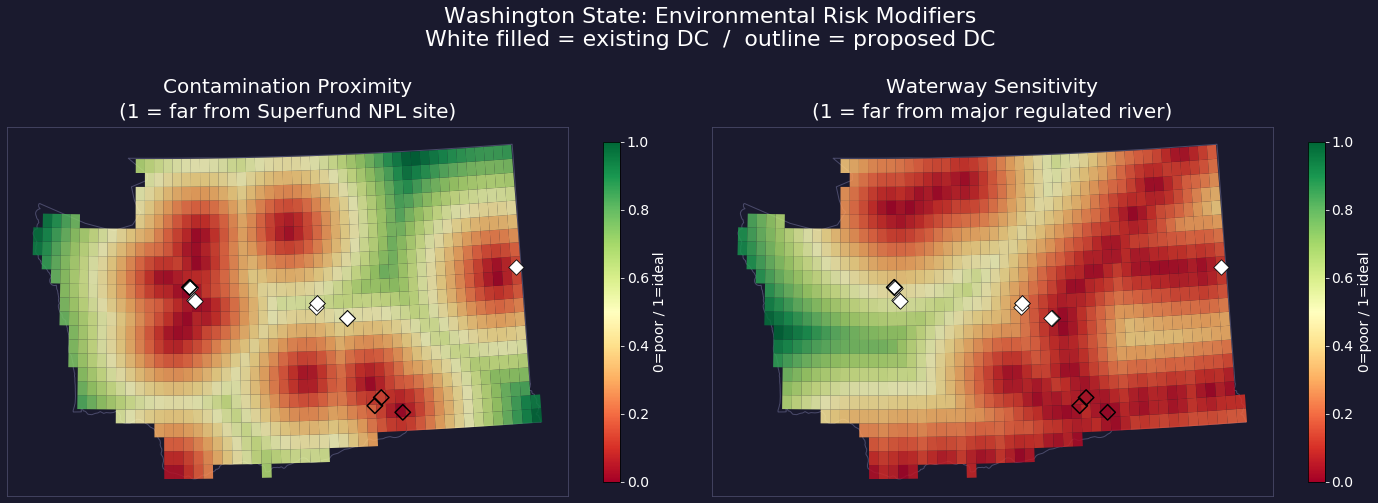

Saved to data/processed/environmental_risk.png


In [5]:
layers = [
    ("contamination_score", "Contamination Proximity",
     "(1 = far from Superfund NPL site)"),
    ("waterway_score",       "Waterway Sensitivity",
     "(1 = far from major regulated river)"),
]

fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor=DARK_BG)

for ax, (col, title, subtitle) in zip(axes, layers):
    ax.set_facecolor(DARK_BG)
    wa.boundary.plot(ax=ax, color="#4a4a6a", linewidth=1.0, zorder=1)
    n_before = len(fig.axes)
    grid.plot(column=col, ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
              legend=True,
              legend_kwds={"shrink": 0.65, "label": "0=poor / 1=ideal"},
              alpha=0.85, zorder=2)
    if len(fig.axes) > n_before:
        cb = fig.axes[-1]
        cb.tick_params(labelsize=14, colors=WHITE)
        cb.yaxis.label.set_color(WHITE)
        cb.yaxis.label.set_size(14)
    _rep  = dc_gdf[dc_gdf["source"] == "reported"]
    _prop = dc_gdf[dc_gdf["source"] == "proposed"]
    ax.scatter(_rep.geometry.x,  _rep.geometry.y,
               c=WHITE, s=120, marker="D", zorder=5,
               edgecolors="black", linewidths=0.8)
    ax.scatter(_prop.geometry.x, _prop.geometry.y,
               facecolors="none", s=120, marker="D", zorder=5,
               edgecolors="black", linewidths=1.5)
    ax.set_title(f"{title}\n{subtitle}", color=WHITE, fontsize=20,
                 pad=10, linespacing=1.4)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor("#4a4a6a")

plt.suptitle(
    "Washington State: Environmental Risk Modifiers\n"
    "White filled = existing DC  /  outline = proposed DC",
    color=WHITE, fontsize=22, y=0.90
)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.savefig(PROCESSED / "environmental_risk.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved to data/processed/environmental_risk.png")


## 5. Export updated grid_scores.geojson


In [6]:
grid_out = grid.drop(columns=["centroid"]).to_crs("EPSG:4326")
grid_out.to_file("static/grid_scores.geojson", driver="GeoJSON")
print(f"Saved static/grid_scores.geojson")
print(f"Columns: {list(grid_out.columns)}")


Saved static/grid_scores.geojson
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geometry']


## 6. Key Findings


In [7]:
print("=== Proposed Sites ===")
for _, row in dc_gdf[dc_gdf["source"] == "proposed"].iterrows():
    pt = row.geometry
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    n = grid.loc[dists.idxmin()]
    print(f'  {row["name"]}:\n'
          f'    contamination={n.contamination_score:.3f}'
          f'  waterway={n.waterway_score:.3f}\n')

print("=== Existing Clusters ===")
seen = set()
for _, row in dc_gdf[dc_gdf["source"] == "reported"].iterrows():
    pt = row.geometry
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    n = grid.loc[dists.idxmin()]
    key = (round(n.contamination_score,2), round(n.waterway_score,2))
    if key not in seen:
        seen.add(key)
        print(f'  {row["name"]}:\n'
              f'    contamination={n.contamination_score:.3f}'
              f'  waterway={n.waterway_score:.3f}\n')


=== Proposed Sites ===
  Digital Realty (proposed):
    contamination=0.009  waterway=0.463

  Amazon Wallula Gap (proposed):
    contamination=0.014  waterway=0.015

  Atlas Agro Richland DC1 (proposed):
    contamination=0.142  waterway=0.046

  Trammell Crow Lewis Clark (proposed):
    contamination=0.207  waterway=0.037

=== Existing Clusters ===
  Microsoft Quincy Campus:
    contamination=0.501  waterway=0.068

  Microsoft EAT06/EAT09:
    contamination=0.554  waterway=0.244

  Equinix SE2 Seattle:
    contamination=0.009  waterway=0.463

  HorizonIQ Seattle (Tukwila):
    contamination=0.028  waterway=0.544

  Verizon Liberty Lake:
    contamination=0.145  waterway=0.116

